In [15]:
import re
import fitz  # PyMuPDF (pip install pymupdf)
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

PDF_PATH = "../data/registration_of_real_estatee_manual.pdf"
HEADING_FONT_SIZE = 11.0     # 섹션 헤딩 폰트 크기 (본문 9.3, 푸터 10.6, 헤딩 11.3)
SECTION_NUM_RE = re.compile(r'^\d+(\.\d+)*\.$')  # 1. / 1.1. / 1.1.1. 매칭
TOC_PAGES = 5                # 앞 5페이지(표지+면책+목차) 스킵

def extract_sections(pdf_path: str, skip_pages: int = TOC_PAGES):
    """
    PyMuPDF span 레벨에서 폰트 크기로 섹션 헤딩을 감지해 섹션을 추출한다.
    헤딩은 size>=11.0인 스팬이 '번호 스팬 → 제목 스팬' 순서로 연속 등장하는 패턴.
    반환: (sections, all_headings)
      - sections    : 본문이 있는 섹션 목록
      - all_headings: {num: title} – 본문 없는 중간 헤딩까지 포함한 전체 헤딩 dict
    """
    doc = fitz.open(pdf_path)
    sections: list = []
    all_headings: dict = {}                                      # breadcrumb용 전체 헤딩
    current = {"num": "0", "title": "머리말", "content": "", "start_page": 1}
    pending_num = None

    for page_idx in range(skip_pages, len(doc)):
        page = doc[page_idx]
        for block in page.get_text("dict")["blocks"]:
            if block["type"] != 0:
                continue
            for line in block["lines"]:
                for span in line["spans"]:
                    text = span["text"].strip()
                    size = span["size"]
                    if not text:
                        continue

                    if size >= HEADING_FONT_SIZE:
                        if SECTION_NUM_RE.match(text):
                            pending_num = text                   # e.g. "1.1."
                        elif pending_num is not None:
                            num_clean = pending_num.rstrip(".")
                            all_headings[num_clean] = text       # 중간 헤딩 포함 전체 기록
                            if current["content"].strip():
                                sections.append(current.copy())
                            current = {
                                "num": num_clean,
                                "title": text,
                                "content": "",
                                "start_page": page_idx + 1,
                            }
                            pending_num = None
                        else:
                            pending_num = None
                    elif size > 10.0:
                        pending_num = None                       # 푸터(10.6) 스킵
                    else:
                        pending_num = None
                        current["content"] += text + "\n"

    if current["content"].strip():
        sections.append(current)

    return sections, all_headings


def get_breadcrumb(num: str, all_headings: dict) -> str:
    """
    '2.1.1' → '소유권보존등기 > 토지소유권보존등기 > 개념및신청인'
    부모 헤딩이 누락된 레벨은 건너뛴다.
    """
    parts = num.split(".")
    crumbs = []
    for i in range(len(parts)):
        prefix = ".".join(parts[: i + 1])
        if prefix in all_headings:
            crumbs.append(all_headings[prefix])
    return " > ".join(crumbs)


sections, all_headings = extract_sections(PDF_PATH)
print(f"추출된 섹션 수: {len(sections)}")
print(f"전체 헤딩 수 (중간 포함): {len(all_headings)}")

추출된 섹션 수: 86
전체 헤딩 수 (중간 포함): 121


In [16]:
# 각 섹션을 LangChain Document로 변환
# page_content 첫 줄에 전체 breadcrumb 포함 → 청크가 분리돼도 상위 맥락 유지
section_docs = [
    Document(
        page_content=f"[{s['num']}] {get_breadcrumb(s['num'], all_headings)}\n\n{s['content'].strip()}",
        metadata={
            "section_num": s["num"],
            "section_title": get_breadcrumb(s["num"], all_headings),
            "start_page": s["start_page"],
        },
    )
    for s in sections
]

# 큰 섹션은 RecursiveCharacterTextSplitter로 추가 분할
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)
chunks = text_splitter.split_documents(section_docs)

print(f"총 섹션: {len(section_docs)}  →  총 청크: {len(chunks)}")

총 섹션: 86  →  총 청크: 315


In [22]:
print("=" * 65)
print("[ 섹션 목록 (처음 15개) ]")
print("=" * 65)
for s in sections[:15]:
    depth = s["num"].count(".") if s["num"] != "0" else 0
    indent = "  " * depth
    print(f"{indent}[{s['num']:12s}]  {s['title'][:40]:<40}  "
          f"p.{s['start_page']}  ({len(s['content'])}자)")

print()
print("=" * 65)
print("[ 청크 샘플 (처음 5개) ]")
print("=" * 65)
for i, c in enumerate(chunks[20:25]):
    print(f"\n--- Chunk {i+1} ---")
    print(f"  section : [{c.metadata['section_num']}] {c.metadata['section_title']}")
    print(f"  page    : {c.metadata['start_page']}")
    print(f"  length  : {len(c.page_content)} chars")
    print("-" * 45)
    print(c.page_content[:400])


[ 섹션 목록 (처음 15개) ]
    [1.1.1       ]  부동산등기의종류및효력                               p.6  (509자)
    [1.2.1       ]  부동산등기의신청과절차                               p.7  (2335자)
    [2.1.1       ]  개념및신청인                                    p.10  (1694자)
    [2.1.2       ]  제출서류                                      p.11  (3155자)
    [2.1.3       ]  신청서작성                                     p.15  (474자)
    [2.1.4       ]  신청절차                                      p.17  (2087자)
    [2.2.1       ]  개념및신청인                                    p.20  (1795자)
    [2.2.2       ]  제출서류                                      p.21  (2390자)
    [2.2.3       ]  신청서작성                                     p.25  (350자)
    [2.2.4       ]  신청절차                                      p.25  (2092자)
    [2.3.1       ]  개념및신청인                                    p.29  (3719자)
    [2.3.2       ]  제출서류                                      p.32  (2594자)
    [2.3.3       ]  신청서작성                                     p.35  (356자)

In [ ]:
# ── 표 + 이미지까지 포함하는 강화 추출 ───────────────────────────────────────

In [ ]:
# # 현재 get_text("dict") 방식의 한계:
# #   - type=1 이미지 블록: 완전 누락 (64 페이지에 존재)
# #   - 표: 평문화되어 구조 손실 (15 페이지에 존재)
# # 해결:
# #   - find_tables() → 마크다운 테이블로 변환
# #   - type=1 블록 → [이미지] 플레이스홀더 삽입
# #   - y좌표 기준 이벤트 정렬 → 섹션 전환 위치와 무관하게 올바른 섹션에 삽입

# def rect_overlap(r1, r2, tol=1):
#     """두 bbox가 겹치는지 확인 (표 영역 텍스트 중복 방지용)"""
#     return not (r1[2] <= r2[0]+tol or r2[2] <= r1[0]+tol or
#                 r1[3] <= r2[1]+tol or r2[3] <= r1[1]+tol)

# def table_to_markdown(tab) -> str:
#     """PyMuPDF Table 객체 → 마크다운 테이블 문자열"""
#     rows = tab.extract()
#     if not rows:
#         return ""
#     def clean(c):
#         return str(c).replace("\n", " ").strip() if c else ""
#     header = [clean(c) for c in rows[0]]
#     body   = [[clean(c) for c in row] for row in rows[1:]]
#     lines  = (
#         ["| " + " | ".join(header) + " |",
#          "|"  + "|".join([" --- " for _ in header]) + "|"] +
#         ["| " + " | ".join(row) + " |" for row in body]
#     )
#     return "\n".join(lines)

# def extract_sections_rich(pdf_path: str, skip_pages: int = TOC_PAGES):
#     """
#     표(find_tables) + 이미지(type-1 블록) 를 포함한 강화 섹션 추출.
#     텍스트 블록·표를 y좌표 기준으로 정렬해 순서대로 처리하므로
#     섹션 전환 위치와 무관하게 표/이미지가 올바른 섹션에 삽입된다.
#     반환: (sections, all_headings)
#     """
#     doc = fitz.open(pdf_path)
#     sections, all_headings = [], {}
#     current = {"num": "0", "title": "머리말", "content": "", "start_page": 1}
#     pending_num = None

#     for page_idx in range(skip_pages, len(doc)):
#         page = doc[page_idx]

#         found      = page.find_tables()
#         tbl_bboxes = [tuple(t.bbox) for t in found.tables]
#         tbl_map    = {tuple(t.bbox): table_to_markdown(t) for t in found.tables}

#         # 텍스트/이미지 블록과 표 이벤트를 y좌표 오름차순으로 정렬
#         events = sorted(
#             [(b["bbox"][1], "block", b)                      for b in page.get_text("dict")["blocks"]] +
#             [(tuple(t.bbox)[1], "table", tuple(t.bbox))      for t in found.tables],
#             key=lambda e: e[0]
#         )

#         for _, etype, obj in events:
#             if etype == "table":
#                 current["content"] += "\n" + tbl_map[obj] + "\n"
#                 continue

#             if obj["type"] == 1:                              # 이미지 블록
#                 current["content"] += "\n[이미지]\n"
#                 continue

#             if any(rect_overlap(obj["bbox"], tb) for tb in tbl_bboxes):
#                 continue                                       # 표 영역 텍스트 중복 방지

#             for line in obj["lines"]:
#                 for span in line["spans"]:
#                     text = span["text"].strip()
#                     size = span["size"]
#                     if not text:
#                         continue

#                     if size >= HEADING_FONT_SIZE:
#                         if SECTION_NUM_RE.match(text):
#                             pending_num = text
#                         elif pending_num is not None:
#                             num_clean = pending_num.rstrip(".")
#                             all_headings[num_clean] = text
#                             if current["content"].strip():
#                                 sections.append(current.copy())
#                             current = {"num": num_clean, "title": text,
#                                        "content": "", "start_page": page_idx + 1}
#                             pending_num = None
#                         else:
#                             pending_num = None
#                     elif size > 10.0:
#                         pending_num = None
#                     else:
#                         pending_num = None
#                         current["content"] += text + "\n"

#     if current["content"].strip():
#         sections.append(current)

#     return sections, all_headings


# sections_rich, all_headings_rich = extract_sections_rich(PDF_PATH)
# print(f"섹션 수            : {len(sections_rich)}")
# print(f"전체 헤딩 수       : {len(all_headings_rich)}")
# print(f"표 포함 섹션 수    : {sum(1 for s in sections_rich if '|' in s['content'])}")
# print(f"이미지 포함 섹션 수: {sum(1 for s in sections_rich if '[이미지]' in s['content'])}")

In [ ]:
# section_docs_rich = [
#     Document(
#         page_content=f"[{s['num']}] {get_breadcrumb(s['num'], all_headings_rich)}\n\n{s['content'].strip()}",
#         metadata={
#             "section_num":   s["num"],
#             "section_title": get_breadcrumb(s["num"], all_headings_rich),
#             "start_page":    s["start_page"],
#         },
#     )
#     for s in sections_rich
# ]
# chunks_rich = text_splitter.split_documents(section_docs_rich)
# print(f"총 섹션: {len(section_docs_rich)}  →  총 청크: {len(chunks_rich)}")

# # 표가 포함된 첫 번째 섹션 확인
# print("\n=== 표 포함 섹션 샘플 ===")
# for s in sections_rich:
#     if "|" in s["content"]:
#         print(f"[{s['num']}] {get_breadcrumb(s['num'], all_headings_rich)}")
#         for line in s["content"].split("\n"):
#             if "|" in line:
#                 print(line)
#         break

# # 이미지 플레이스홀더 확인
# print("\n=== 이미지 플레이스홀더 포함 섹션 (처음 3개) ===")
# for s in sections_rich:
#     if "[이미지]" in s["content"]:
#         print(f"  [{s['num']}] {get_breadcrumb(s['num'], all_headings_rich)}  p.{s['start_page']}")

---
## 방법 비교: ① 순수 Recursive Chunking  vs  ② 섹션분리 + Recursive Chunking

| | ① 순수 Recursive | ② 섹션분리 + Recursive |
|---|---|---|
| **추출 방식** | `get_text("text")` 페이지 단위 평문 | 폰트 크기로 섹션 헤딩 감지 → 섹션 단위 분할 |
| **표** | 셀이 개행으로 평탄화, 행·열 구조 소실 | 동일하게 평탄화 (find_tables 미사용) |
| **이미지** | 완전 누락 | 동일하게 누락 (type-1 블록 미처리) |
| **맥락** | 섹션 정보 없음, 페이지 번호만 | breadcrumb 헤더 + section_num 메타데이터 보존 |

> **이번 비교 핵심**: 섹션 분리 자체가 청크 품질에 어떤 영향을 주는지 확인한다.  
> 표·이미지의 완전한 처리는 `extract_sections_rich` (find_tables + 이미지 플레이스홀더) 버전에서 다룬다.

In [18]:
# ── 방법 ①: 순수 Recursive Chunking ─────────────────────────────────────────
# get_text("text")로 페이지별 단순 추출 → 섹션 구분 없이 RecursiveCharacterTextSplitter 적용
# 비교 대상 ②: 기존 sect_extract_01~02 셀에서 만든 chunks (extract_sections 기반)

def extract_plain_text_by_page(pdf_path: str, skip_pages: int = TOC_PAGES):
    """페이지 단위 단순 텍스트 추출 (섹션·표·이미지 구조 없음)"""
    doc = fitz.open(pdf_path)
    page_docs = []
    for page_idx in range(skip_pages, len(doc)):
        text = doc[page_idx].get_text("text").strip()
        if text:
            page_docs.append(Document(
                page_content=text,
                metadata={"page": page_idx + 1}
            ))
    return page_docs

plain_docs   = extract_plain_text_by_page(PDF_PATH)
chunks_plain = text_splitter.split_documents(plain_docs)  # 동일한 splitter 사용

# 이미지가 실제로 존재하는 페이지 탐색 (비교에서 사용)
_doc = fitz.open(PDF_PATH)
IMG_PAGES = [
    page_idx + 1
    for page_idx in range(TOC_PAGES, len(_doc))
    if any(b["type"] == 1 for b in _doc[page_idx].get_text("dict")["blocks"])
]
print(f"이미지 포함 페이지 (PDF 기준): {IMG_PAGES[:10]}")
print()
print("=" * 55)
print(f"  방법 ①  순수 Recursive         청크 수 : {len(chunks_plain):>5}")
print(f"  방법 ②  섹션분리 + Recursive   청크 수 : {len(chunks):>5}")
print("=" * 55)

이미지 포함 페이지 (PDF 기준): [8, 13, 15, 16, 17, 19, 24, 26, 28, 34]

  방법 ①  순수 Recursive         청크 수 :   281
  방법 ②  섹션분리 + Recursive   청크 수 :   315


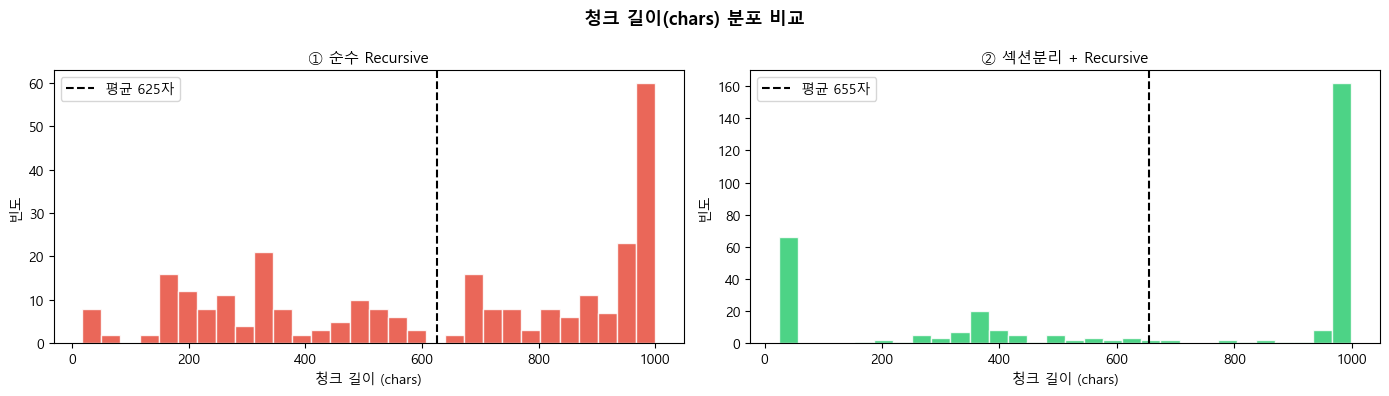

,① 순수 Recursive,② 섹션분리 + Recursive
지표,,
총 청크 수,281,315
평균 길이(chars),625,655
중앙값(chars),679,972
최소 길이,17,24
최대 길이,1000,999
섹션 breadcrumb 포함 청크,0,315
section_num 메타데이터 보유,0,315
이미지 포함 청크 (플레이스홀더),0,0


In [19]:
# ── 청크 통계 비교 ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        matplotlib.rc("font", family=font)
        break
    except Exception:
        pass
matplotlib.rcParams["axes.unicode_minus"] = False

sizes_plain = [len(c.page_content) for c in chunks_plain]
sizes_sect  = [len(c.page_content) for c in chunks]

# ── 히스토그램 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
fig.suptitle("청크 길이(chars) 분포 비교", fontsize=13, fontweight="bold")

for ax, sizes, color, label in [
    (axes[0], sizes_plain, "#e74c3c", "① 순수 Recursive"),
    (axes[1], sizes_sect,  "#2ecc71", "② 섹션분리 + Recursive"),
]:
    ax.hist(sizes, bins=30, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(np.mean(sizes), color="black", linestyle="--", linewidth=1.5,
               label=f"평균 {np.mean(sizes):.0f}자")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("청크 길이 (chars)")
    ax.set_ylabel("빈도")
    ax.legend()

plt.tight_layout()
plt.show()

# ── 요약 테이블 ──────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "지표": [
        "총 청크 수", "평균 길이(chars)", "중앙값(chars)",
        "최소 길이", "최대 길이",
        "섹션 breadcrumb 포함 청크",
        "section_num 메타데이터 보유",
        "이미지 포함 청크 (플레이스홀더)",
    ],
    "① 순수 Recursive": [
        len(chunks_plain),
        f"{np.mean(sizes_plain):.0f}",
        f"{np.median(sizes_plain):.0f}",
        min(sizes_plain), max(sizes_plain),
        0,
        0,
        0,
    ],
    "② 섹션분리 + Recursive": [
        len(chunks),
        f"{np.mean(sizes_sect):.0f}",
        f"{np.median(sizes_sect):.0f}",
        min(sizes_sect), max(sizes_sect),
        sum(1 for c in chunks if c.metadata.get("section_title")),
        sum(1 for c in chunks if c.metadata.get("section_num")),
        0,  # extract_sections는 이미지 플레이스홀더 미지원
    ],
})
summary.set_index("지표")

In [20]:
# ── 표(Table) 처리 비교 ────────────────────────────────────────────────────────
# 15 페이지(2.1.3 신청서작성 섹션 근처) 부근 청크를 나란히 보여준다.
# 두 방식 모두 표 구조를 살리지 못하지만, ②는 섹션 breadcrumb로 어느 맥락의 표인지 알 수 있다.

from IPython.display import display, HTML
import html as html_module

def _render_content(text: str, max_chars: int = 700) -> str:
    escaped = html_module.escape(text[:max_chars])
    lines = escaped.split("\n")
    out = []
    for line in lines:
        if "|" in line and "---" not in line:
            out.append(f'<span style="background:#d5f5e3;font-weight:bold;display:block">{line}</span>')
        elif "---" in line and "|" in line:
            out.append(f'<span style="background:#aed6f1;display:block">{line}</span>')
        elif "[이미지]" in line:
            out.append(f'<span style="background:#fdebd0;font-weight:bold;display:block">{line}</span>')
        elif line.strip() and all(c in "─│├┤┬┴┼╔╗╚╝║═" for c in line.strip()):
            out.append(f'<span style="background:#fef9c3;display:block">{line}</span>')
        else:
            out.append(f'<span style="display:block">{line}</span>')
    if len(text) > max_chars:
        out.append('<span style="color:#aaa">… (이하 생략)</span>')
    return "".join(out)

# 표가 있는 페이지(15) 부근 청크
plain_tbl_chunks = [c for c in chunks_plain if c.metadata.get("page") in (14, 15, 16)]
# ② 섹션기반: 2.1.2(제출서류) 또는 2.1.3(신청서작성) 섹션 청크
sect_tbl_chunks = [c for c in chunks
                   if c.metadata.get("section_num", "").startswith("2.1")]

def _chunk_card(chunk, color, idx):
    meta = chunk.metadata
    if "section_num" in meta:
        badge = f'섹션: <b>{meta["section_num"]}</b> {html_module.escape(meta.get("section_title","")[:45])}'
    else:
        badge = f'page: {meta.get("page","?")}'
    return f"""
    <div style="margin:6px 0;padding:10px;background:#fafafa;
                border-left:4px solid {color};border-radius:4px;font-size:11px">
      <div style="color:{color};font-weight:bold;margin-bottom:4px">
        Chunk #{idx+1} &nbsp;|&nbsp; {badge} &nbsp;|&nbsp; {len(chunk.page_content)}자
      </div>
      <div style="font-family:monospace;white-space:pre-wrap;line-height:1.5">
        {_render_content(chunk.page_content)}
      </div>
    </div>"""

cards_plain = "".join(_chunk_card(c, "#e74c3c", i) for i, c in enumerate(plain_tbl_chunks[:3]))
cards_sect  = "".join(_chunk_card(c, "#27ae60", i) for i, c in enumerate(sect_tbl_chunks[:3]))

display(HTML(f"""
<div style="font-family:sans-serif">
  <h3 style="margin-bottom:4px">표(Table) 처리 비교 — page 14~16 영역</h3>
  <div style="font-size:11px;margin-bottom:8px;color:#555">
    두 방식 모두 표 셀을 개행으로 평탄화한다. 차이는 <b>섹션 맥락 보존 여부</b>에 있다.
  </div>
  <div style="display:flex;gap:16px">
    <div style="flex:1;border:2px solid #e74c3c;padding:12px;border-radius:8px">
      <h4 style="color:#e74c3c;margin:0 0 8px">① 순수 Recursive — page 14~16 청크</h4>
      <p style="color:#777;font-size:11px;margin:0 0 8px">
        ❌ 표 구조 소실: 셀 값이 개행으로만 나열됨<br>
        ❌ 섹션 정보 없음: 이 내용이 어느 절차의 서류 목록인지 알 수 없음<br>
        ❌ 페이지 경계에서 표가 잘릴 경우 전후 맥락 단절
      </p>
      {cards_plain or '<div style="color:#aaa;padding:8px">해당 페이지 청크 없음</div>'}
    </div>
    <div style="flex:1;border:2px solid #27ae60;padding:12px;border-radius:8px">
      <h4 style="color:#27ae60;margin:0 0 8px">② 섹션분리 + Recursive — 2.1.x 섹션 청크</h4>
      <p style="color:#777;font-size:11px;margin:0 0 8px">
        ⚠️ 표 구조 동일하게 소실 (find_tables 미사용)<br>
        ✅ breadcrumb 헤더로 "소유권보존등기 &gt; 토지 &gt; 제출서류"임을 청크 내에 명시<br>
        ✅ section_num 메타데이터로 필터링·재순위화 가능
      </p>
      {cards_sect or '<div style="color:#aaa;padding:8px">해당 섹션 청크 없음</div>'}
    </div>
  </div>
  <div style="margin-top:12px;padding:10px;background:#fffbe6;border-left:4px solid #f39c12;
              border-radius:4px;font-size:12px">
    💡 표 행·열 구조까지 보존하려면 주석 처리된 <code>extract_sections_rich</code>를 활성화해
    <code>find_tables()</code> → 마크다운 변환 경로를 사용해야 한다.
  </div>
</div>
"""))

In [21]:
# ── 이미지(Figure) 처리 비교 ──────────────────────────────────────────────────
# IMG_PAGES: 앞 셀에서 탐색한 이미지 포함 페이지 목록
# 두 방식 모두 이미지를 추출하지 못한다. 차이는 "이미지 주변 텍스트의 섹션 맥락 보존 여부"다.

_doc = fitz.open(PDF_PATH)

# ① 이미지 페이지의 get_text 결과 (이미지 자체는 없고 주변 텍스트만)
img_page_raw = {}
for pg in IMG_PAGES[:3]:
    raw = _doc[pg - 1].get_text("text").strip()
    img_page_raw[pg] = raw if raw else None

# ② 섹션기반: 이미지 페이지를 start_page로 포함하는 섹션의 청크
img_page_set = set(IMG_PAGES[:5])
sect_img_chunks = [
    c for c in chunks
    if c.metadata.get("start_page") in img_page_set
]
# 없으면 IMG_PAGES 근처 페이지 섹션 확장 탐색
if not sect_img_chunks:
    near_pages = set()
    for p in IMG_PAGES[:5]:
        near_pages.update([p-1, p, p+1])
    sect_img_chunks = [c for c in chunks if c.metadata.get("start_page") in near_pages]

left_cards = ""
for pg, raw_text in img_page_raw.items():
    is_empty = raw_text is None
    bg = "#fff5f5" if is_empty else "#fafafa"
    label = "❌ 텍스트 없음 → 청크 미생성 (이미지 블록만 존재)" if is_empty else "⚠️ 주변 텍스트는 추출됐으나 이미지 누락"
    content = html_module.escape(raw_text[:500]) if raw_text else "(내용 없음)"
    left_cards += f"""
    <div style="margin:6px 0;padding:10px;background:{bg};
                border-left:4px solid #e74c3c;border-radius:4px;font-size:11px">
      <div style="color:#e74c3c;font-weight:bold;margin-bottom:4px">page {pg} &nbsp;|&nbsp; {label}</div>
      <div style="font-family:monospace;white-space:pre-wrap;line-height:1.5;color:#333">{content}</div>
    </div>"""

right_cards = ""
for i, c in enumerate(sect_img_chunks[:3]):
    right_cards += f"""
    <div style="margin:6px 0;padding:10px;background:#f0fdf4;
                border-left:4px solid #27ae60;border-radius:4px;font-size:11px">
      <div style="color:#27ae60;font-weight:bold;margin-bottom:4px">
        Chunk #{i+1} &nbsp;|&nbsp;
        섹션: <b>{c.metadata.get('section_num','')}</b>
        {html_module.escape(c.metadata.get('section_title','')[:45])}
        &nbsp;p.{c.metadata.get('start_page','?')} &nbsp;|&nbsp; {len(c.page_content)}자
      </div>
      <div style="font-family:monospace;white-space:pre-wrap;line-height:1.5">
        {_render_content(c.page_content, max_chars=500)}
      </div>
    </div>"""

no_right = '<div style="color:#aaa;padding:8px">해당 페이지 근처 섹션 청크 없음</div>'

display(HTML(f"""
<div style="font-family:sans-serif">
  <h3 style="margin-bottom:4px">이미지(Figure) 처리 비교</h3>
  <div style="font-size:11px;margin-bottom:8px;color:#555">
    두 방식 모두 이미지 자체는 추출 불가. 차이는 <b>이미지가 있던 위치의 섹션 맥락 보존 여부</b>다.
  </div>
  <div style="display:flex;gap:16px">
    <div style="flex:1;border:2px solid #e74c3c;padding:12px;border-radius:8px">
      <h4 style="color:#e74c3c;margin:0 0 8px">① 순수 Recursive — 이미지 페이지 원문</h4>
      <p style="color:#777;font-size:11px;margin:0 0 8px">
        ❌ 이미지 블록 완전 무시 (get_text 한계)<br>
        ❌ 텍스트가 없는 페이지 → 청크 자체 미생성<br>
        ❌ 이미지가 있었다는 사실조차 청크에 남지 않음
      </p>
      {left_cards}
    </div>
    <div style="flex:1;border:2px solid #27ae60;padding:12px;border-radius:8px">
      <h4 style="color:#27ae60;margin:0 0 8px">② 섹션분리 + Recursive — 이미지 페이지 근처 섹션 청크</h4>
      <p style="color:#777;font-size:11px;margin:0 0 8px">
        ⚠️ 이미지 자체 누락은 동일<br>
        ✅ 이미지 주변 텍스트가 올바른 섹션에 귀속됨<br>
        ✅ "이 이미지가 어느 절차 설명에 속했는지" breadcrumb으로 추론 가능
      </p>
      {right_cards if right_cards else no_right}
    </div>
  </div>
  <div style="margin-top:12px;padding:10px;background:#fffbe6;border-left:4px solid #f39c12;
              border-radius:4px;font-size:12px">
    💡 이미지 위치를 텍스트로 보존하려면 주석 처리된 <code>extract_sections_rich</code>를 활성화해
    type-1 블록 → <code>[이미지]</code> 플레이스홀더 삽입 경로를 사용해야 한다.
  </div>
  <div style="margin-top:8px;padding:10px;background:#f0f4ff;border-left:4px solid #3498db;
              border-radius:4px;font-size:12px">
    <b>세 방식 비교 요약</b><br>
    &nbsp;&nbsp;① 순수 Recursive &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;: 표 구조 소실, 이미지 누락, 섹션 맥락 없음<br>
    &nbsp;&nbsp;② 섹션분리 + Recursive : 표 구조 소실, 이미지 누락, <b>섹션 맥락 보존</b><br>
    &nbsp;&nbsp;③ 섹션분리 Rich 버전 &nbsp;: <b>표 마크다운 변환</b>, <b>[이미지] 플레이스홀더</b>, 섹션 맥락 보존
  </div>
</div>
"""))